# Unified treatment of all our hypotheses:
# 1. Hypothesis: $Y = A Q B Q^t$, with $A = diag(\lambda)$, $B = diag(\phi)$, with SVD $Y = U S V^t$, 
# with $S = diag(\psi)$, and $Q$, $U$, $V$ all orthogonal. 
# Which of the following are true, as $d \rightarrow \infty$?
# 1.1 : $(Tr(Y))^2 / Tr(Y^2) \rightarrow \nu(\psi)$
# 1.2 : $Tr(Y) / Tr(S) \rightarrow 1$
# 1.3 : $Tr(Y^2) / Tr(S^2) \rightarrow 1$
# 1.4 : Does uniform / Cauchy / Pareto make any difference?
# 1.5 : If $\lambda \sim Pareto(\alpha)$, and $\phi \sim Pareto(\beta)$, 
# does convergence depend on $\alpha$, $\beta$?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

# 1 (i) Uniform

In [2]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_uniform"] = True
this_config["B_diagonal"] = True
this_config["B_uniform"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.]
[1.]
generating A
A is diagonal
A is uniform
generating B
B is diagonal
B is uniform
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is uniform
generating B
B is diagonal
B is uniform
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calc

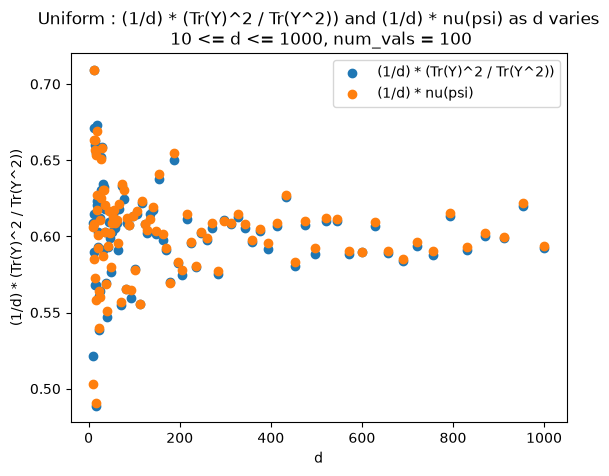

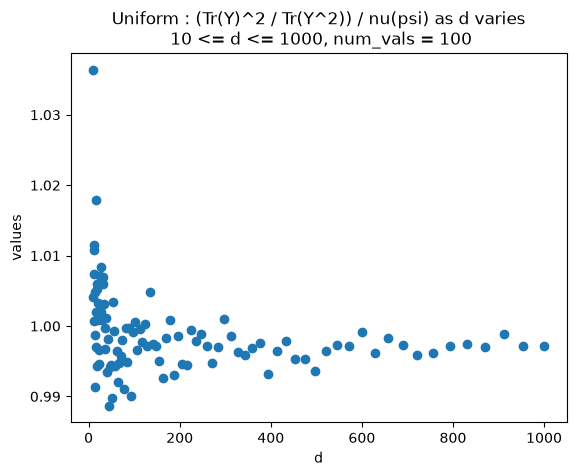

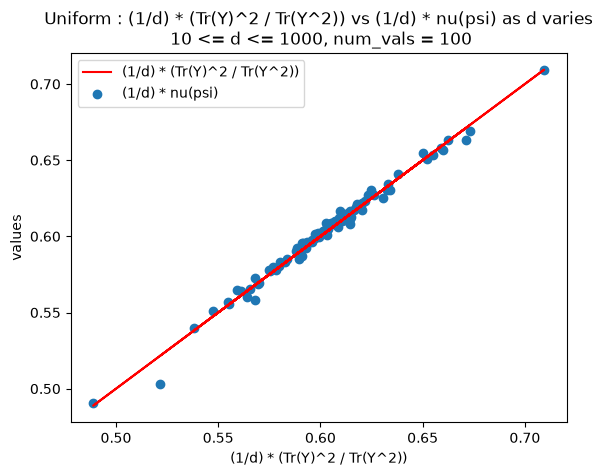

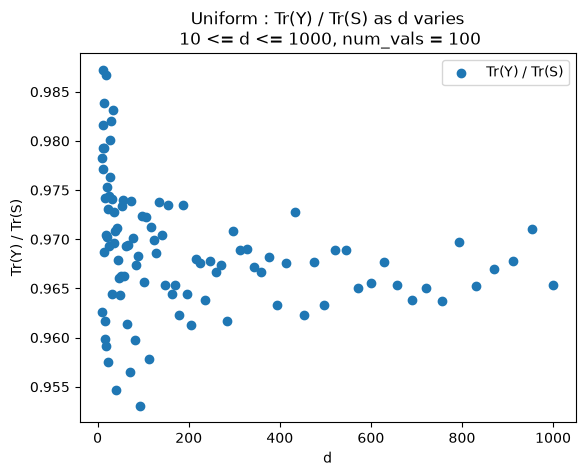

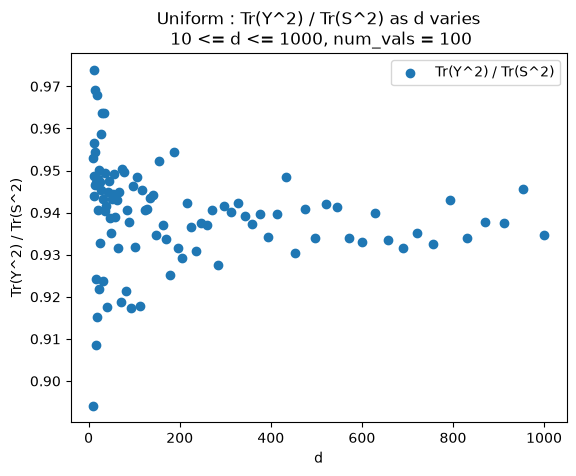

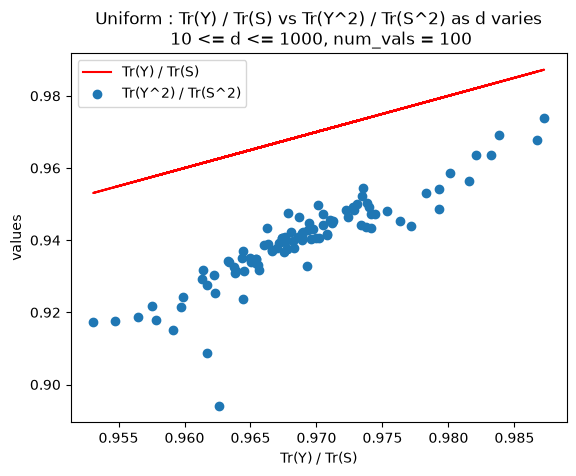

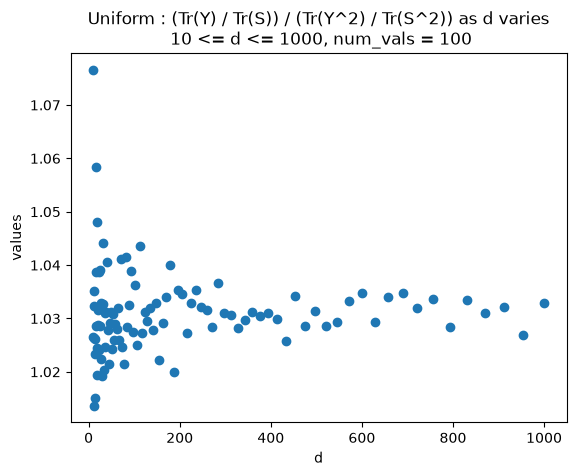

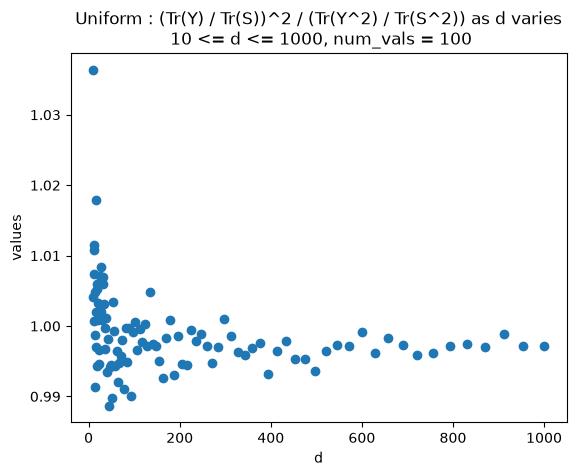

In [3]:
pp.plot_one(xx, "Uniform")

# (ii) Cauchy

In [5]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_cauchy"] = True
this_config["B_diagonal"] = True
this_config["B_cauchy"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.]
[1.]
generating A
A is diagonal
A is Cauchy
generating B
B is diagonal
B is Cauchy
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is Cauchy
generating B
B is diagonal
B is Cauchy
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculat

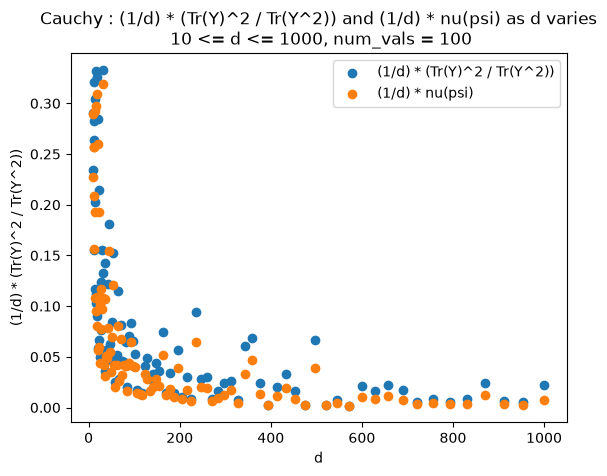

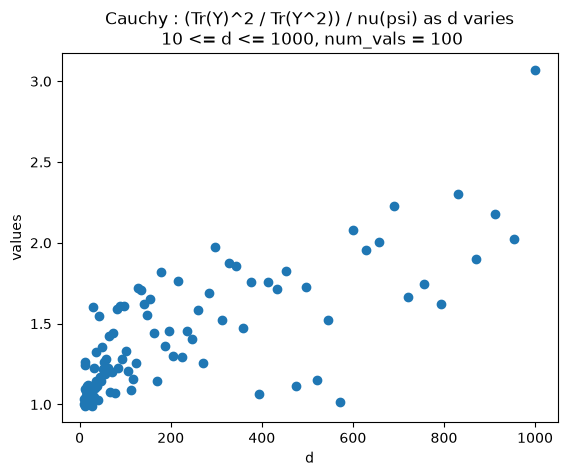

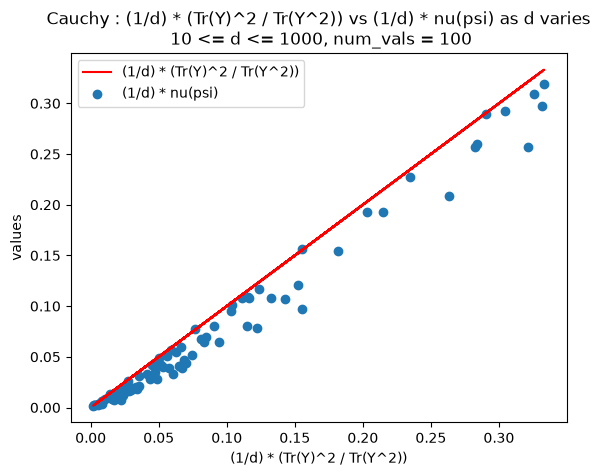

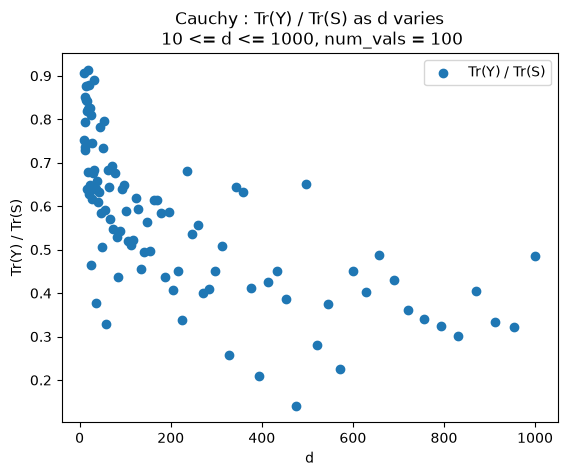

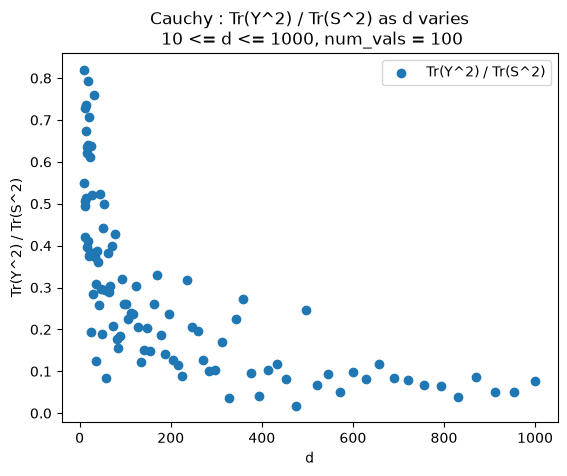

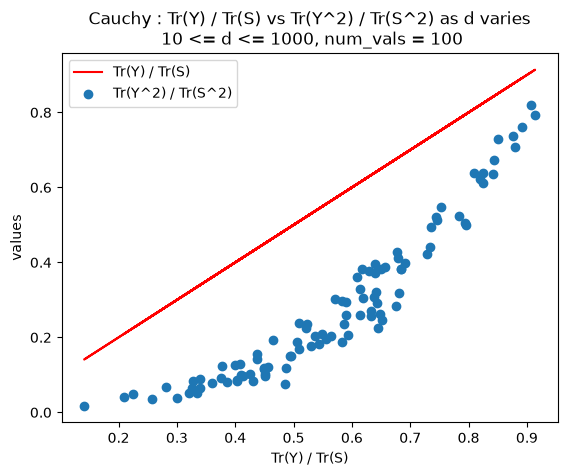

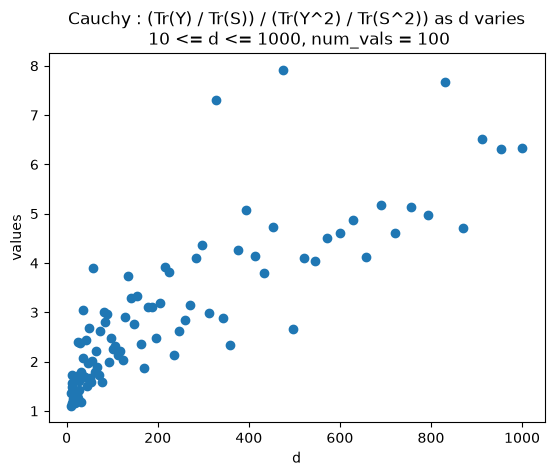

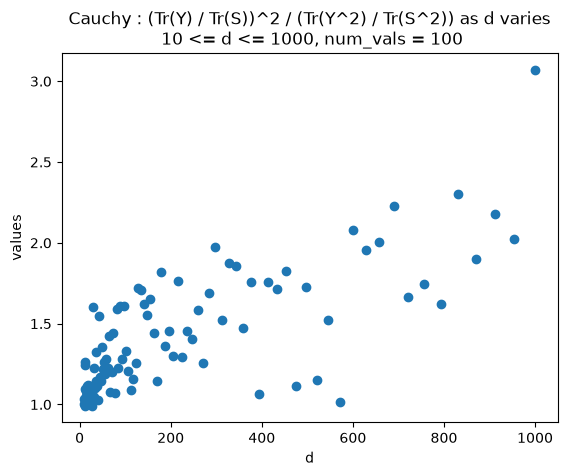

In [6]:
pp.plot_one(xx, "Cauchy")

# (iii) Pareto, fix alpha, beta, allow d to vary

In [8]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 2.0
B_beta = 3.0
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]
[3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3.]
generating A
A is diagonal
A is

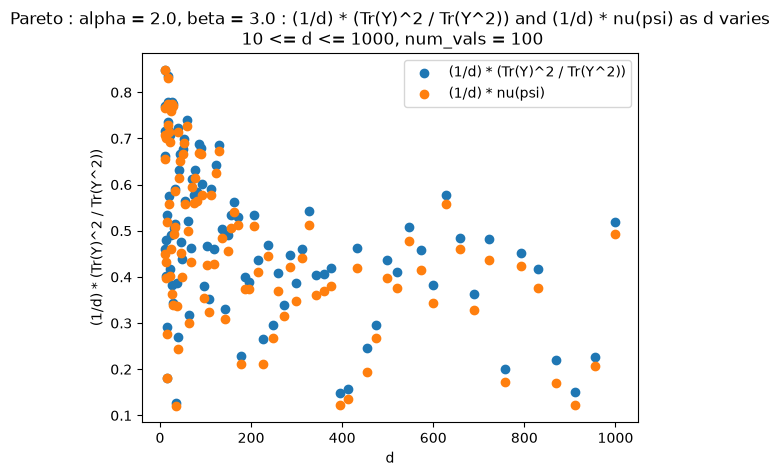

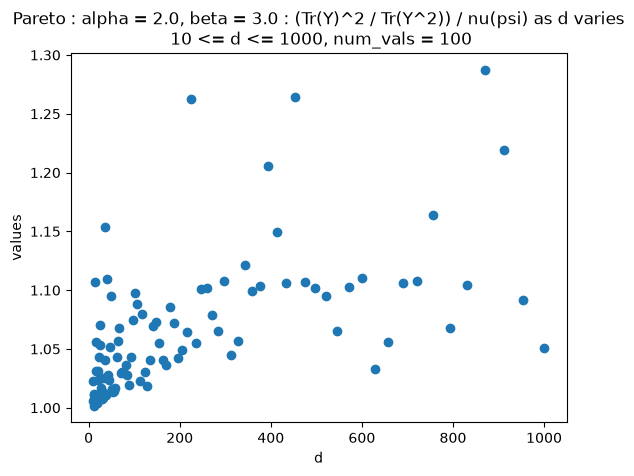

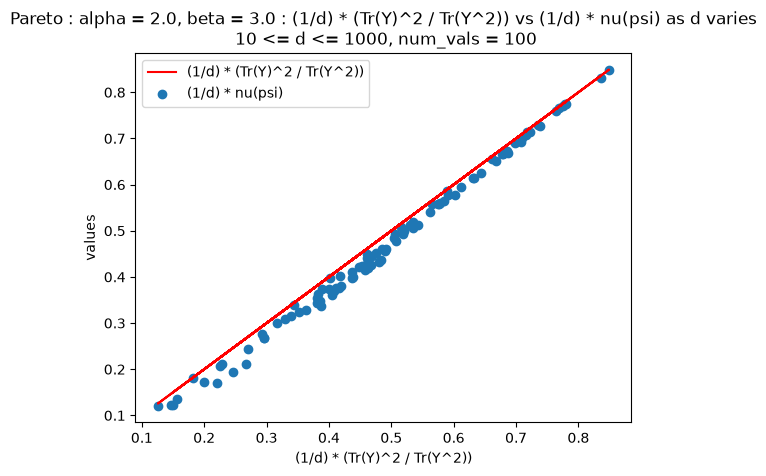

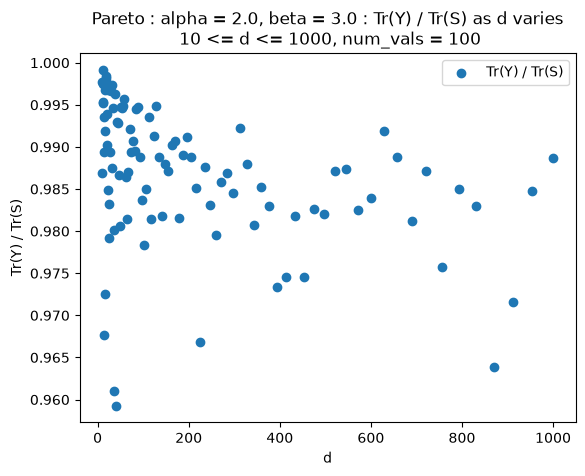

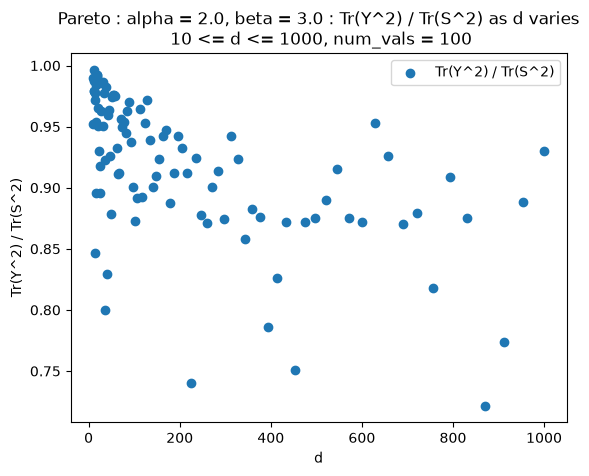

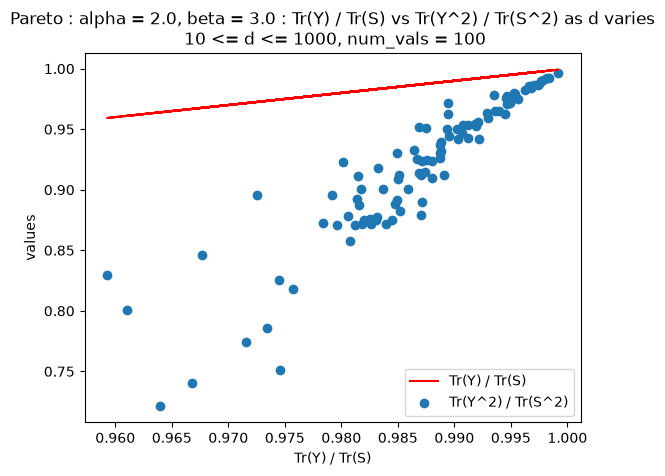

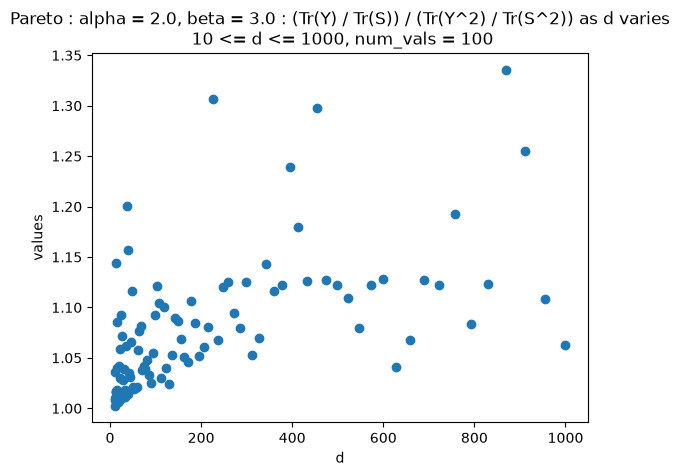

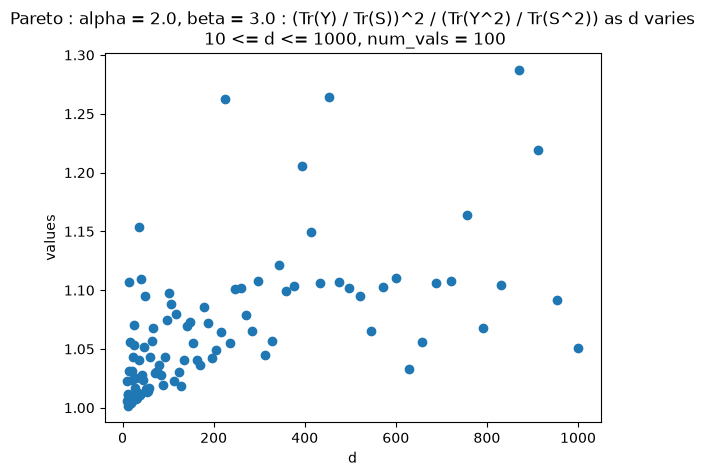

In [9]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

# More Pareto

In [10]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 1.5
B_beta = 1.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 

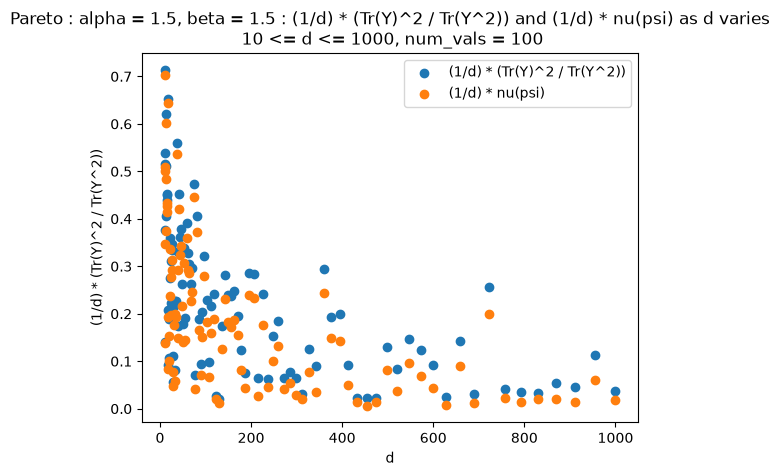

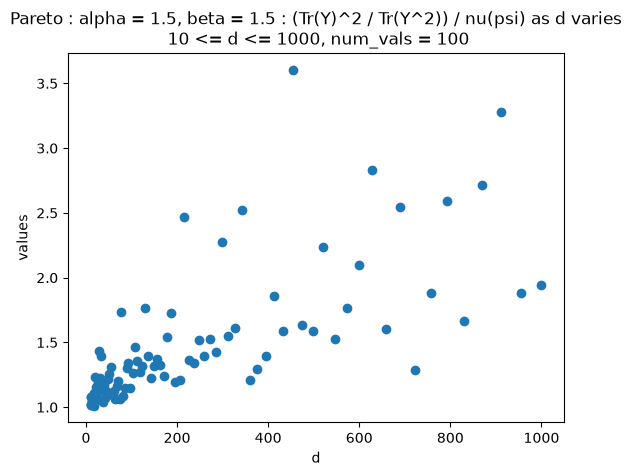

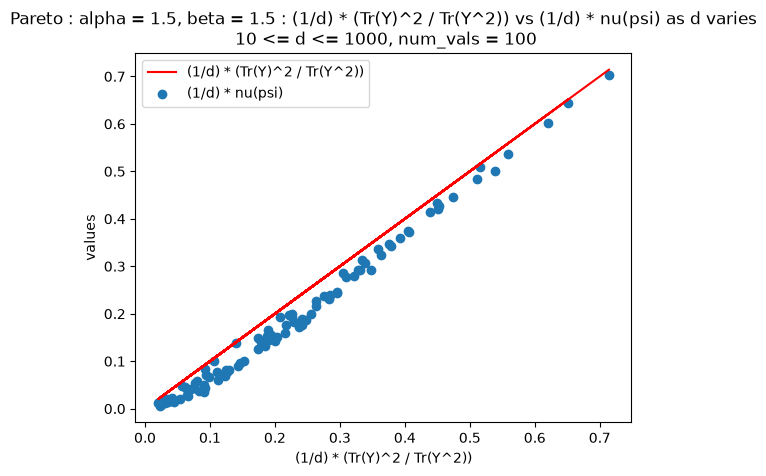

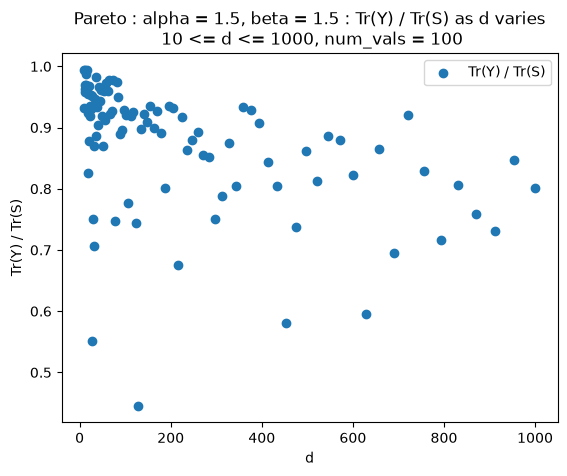

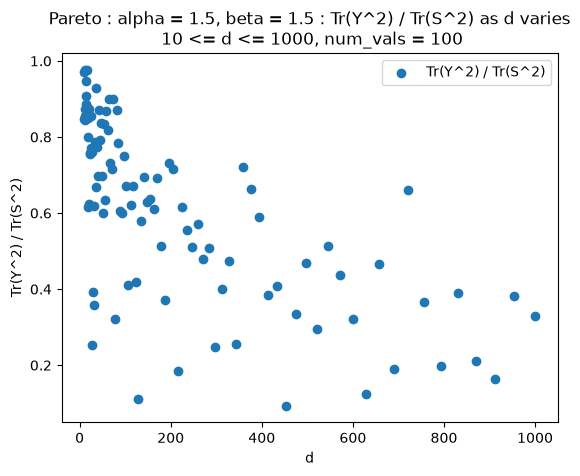

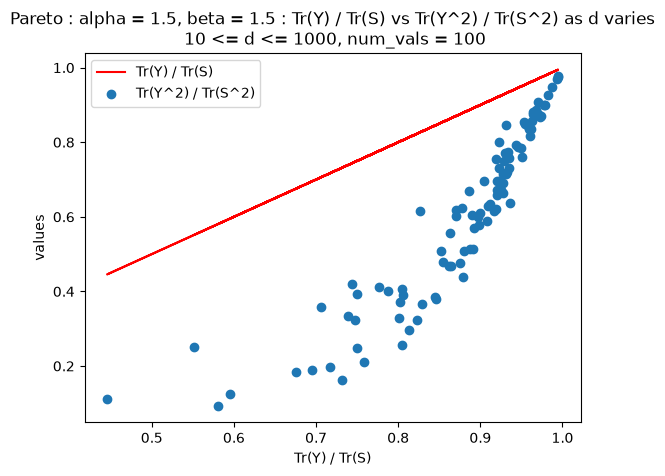

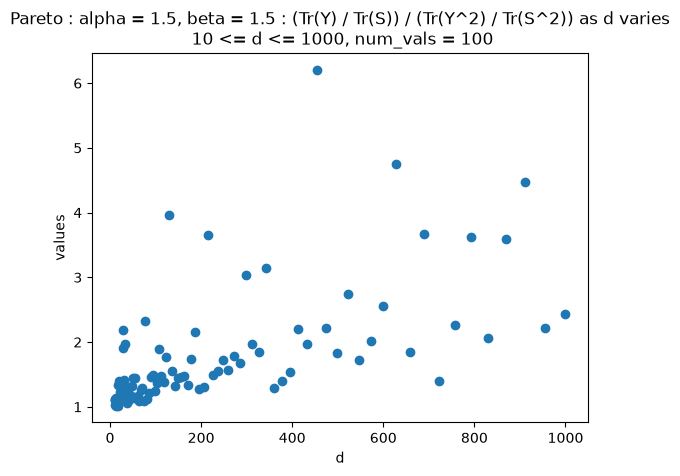

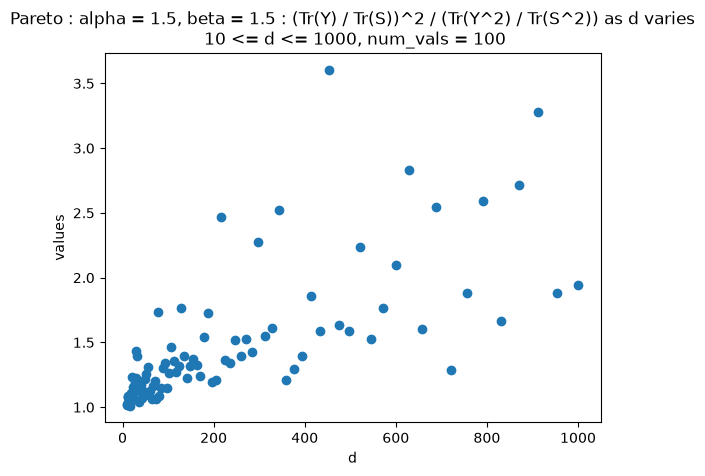

In [11]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

# More Pareto

In [12]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 1000
max_d = 2000
num_steps = 10
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 1.5
B_beta = 1.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (1000, 1000)
Q.shape =  (1000, 1000)
B.shape =  (1000, 1000)
Qt.shape =  (1000, 1000)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (1080, 1080)
Q.shape =  (1080, 1080)
B.shape =  (1080, 1080)
Qt.shape =  (1080, 1080)
** calculate_nu_cpu

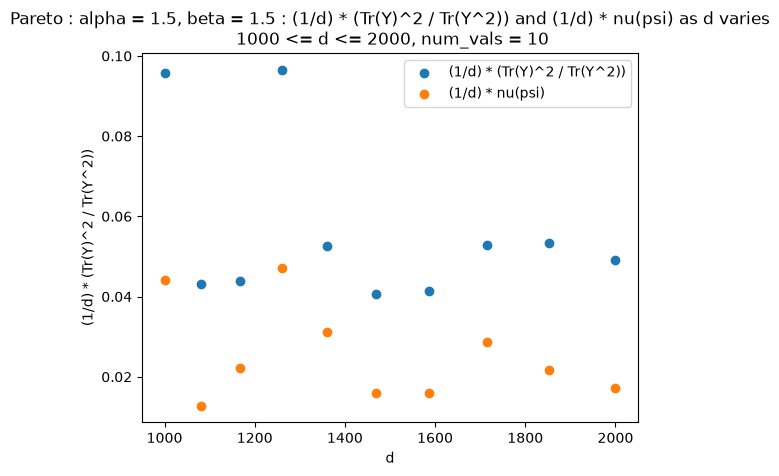

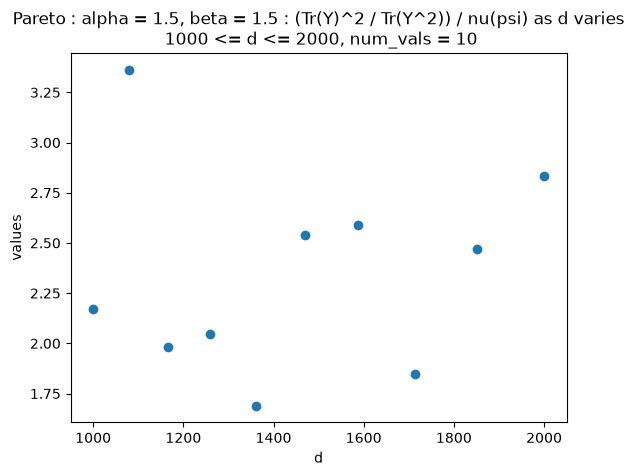

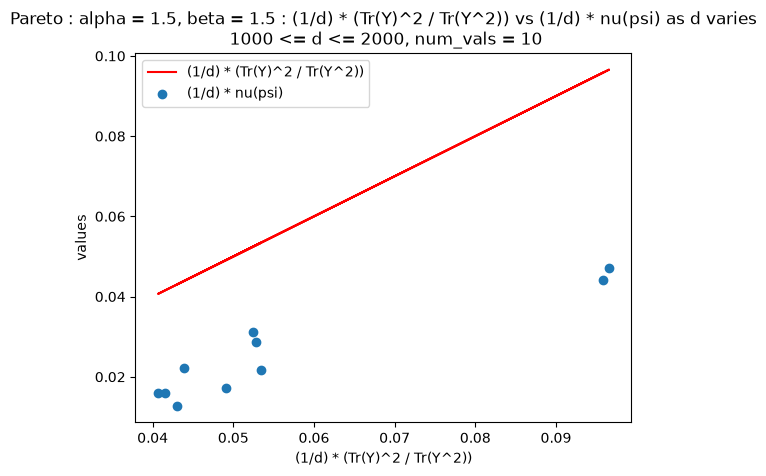

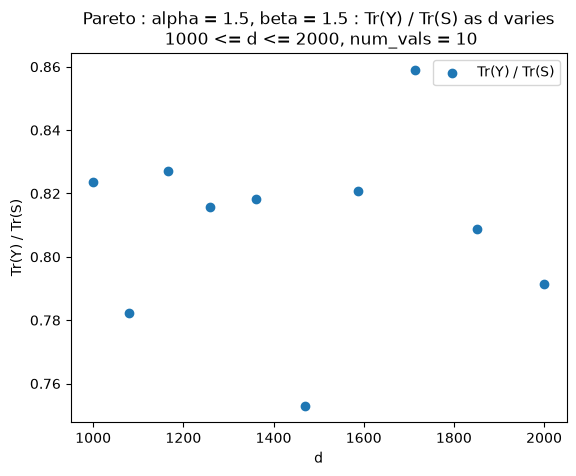

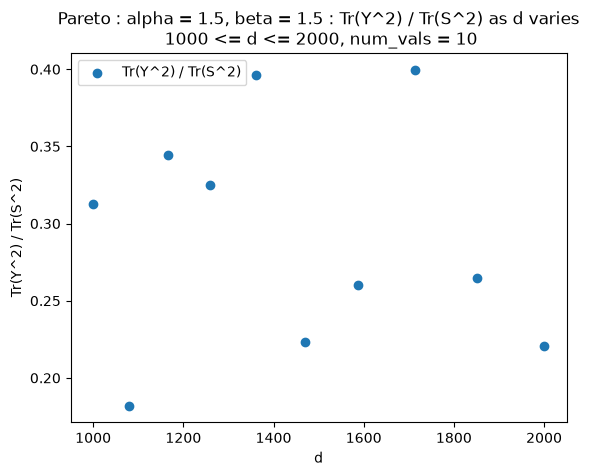

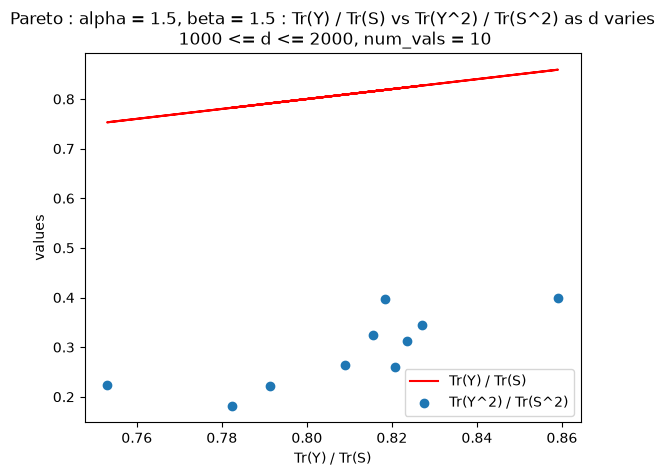

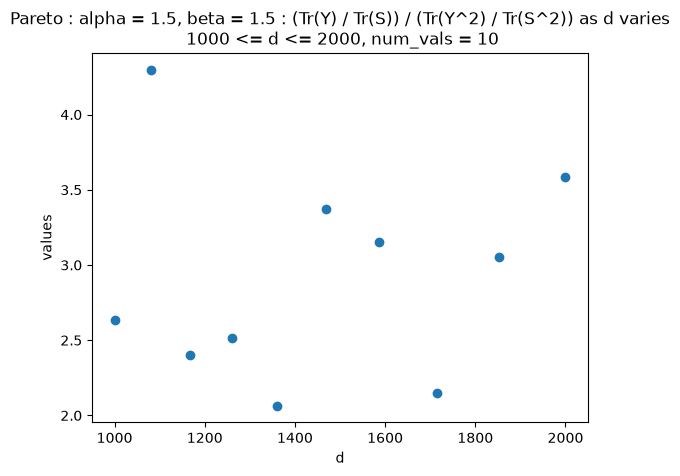

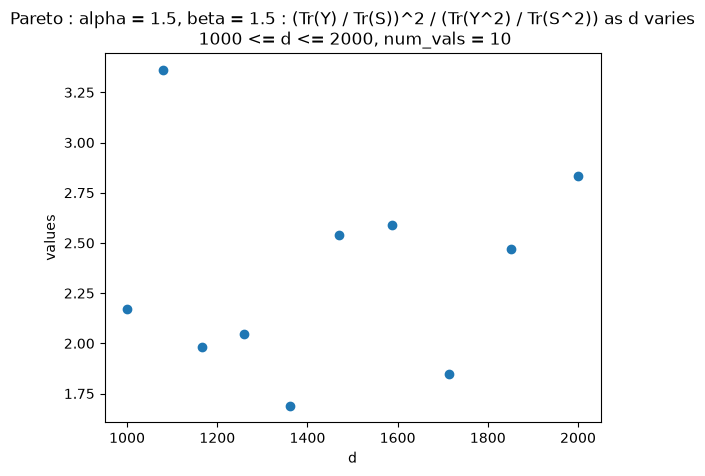

In [13]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [14]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 1000
num_steps = 50
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.5
B_beta = 1.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (100, 100)
Q.shape =  (100, 100)
B.shape =  (100, 100)
Qt.shape =  (100, 100)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 2000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.5
B_beta = 0.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.5
B_beta = 5.0
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 2.1
B_beta = 2.1
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 2000
num_steps = 50
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.1
B_beta = 0.1
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
plot_one(xx, this_prefix)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
plot_one(xx, this_prefix)